# Análisis de contribución por canal económico

Quinto cuaderno. A diferencia de los anteriores, no busca un modelo nuevo para el ranking, sino
**responder una pregunta**: de los siete canales económicos del panel (laboral, precios, energía,
industrial, macro, cambiario y crédito-banca), ¿cuál aporta capacidad predictiva sobre la tasa de paro,
y cuánta, una vez se tiene en cuenta la propia inercia de la serie?

La motivación es directa. Los cuadernos previos han mostrado, con SARIMAX, Prophet y los modelos de
aprendizaje automático, que los regresores macroeconómicos no mejoran al modelo univariante, y que la
predicción la domina el primer rezago del paro. Este cuaderno lo cuantifica **canal por canal** para
cerrar la cuestión de forma ordenada y dejar constancia de qué información económica añade algo y cuál
no, lo que es en sí un resultado para la memoria.

## Cómo se mide la contribución

Se parte de un **modelo base autorregresivo**, una regresión Lasso sobre los rezagos de la propia tasa
de paro, que captura la inercia. A ese esqueleto se le añaden, de uno en uno, los regresores de cada
canal, y se mide la diferencia de RMSE fuera de muestra en el mismo expanding window. La contribución
de un canal es cuánto baja el error al incorporarlo: positiva si ayuda, nula o negativa si no aporta o
estorba. Se usa Lasso porque su penalización controla la alta dimensionalidad y sus coeficientes no
nulos dicen, de forma directa, qué variables retiene el modelo.

## 1. Datos y construcción de los conjuntos por canal

Se cargan los siete `Datasets Modelado/canal_*_estacionario_modelado.csv`, se reúne el universo de
regresores y se añaden los rezagos de la tasa de paro (de 1 a 4 trimestres), conocidos en el origen.
Cada conjunto de variables es el esqueleto autorregresivo más, en su caso, los regresores de un canal.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Lasso

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RAIZ = Path.cwd().parent if Path.cwd().name == "Modelos" else Path.cwd()
RUTA_DATOS = RAIZ / "Datasets Modelado"
RUTA_RESULTADOS = RAIZ / "Resultados"

TARGET = "tasa_paro_total"
DUMMY = "dummy_2020Q2"
HORIZONTES = [0, 1, 2, 3, 4]
PRIMER_TEST = "1996Q1"
VAL_INI, VAL_FIN = "1989Q1", "1994Q4"
RANGO_PLAUSIBLE = (0.0, 60.0)
MARGEN_SALTO = 2.0
AR_LAGS = [1, 2, 3, 4]
CANALES = ["laboral", "precios", "energia", "industrial", "macro", "cambiario", "credito_banca"]

# Master con fecha, target, dummy y todos los regresores de los canales (columnas unicas)
base = pd.read_csv(RUTA_DATOS / "canal_macro_estacionario_modelado.csv", parse_dates=["fecha"])[["fecha", TARGET, DUMMY]]
VARS_CANAL = {}
for c in CANALES:
    d = pd.read_csv(RUTA_DATOS / f"canal_{c}_estacionario_modelado.csv", parse_dates=["fecha"])
    vc = [col for col in d.columns if col not in ["fecha", TARGET, DUMMY]]
    VARS_CANAL[c] = vc
    nuevas = [col for col in vc if col not in base.columns]
    base = base.merge(d[["fecha"] + nuevas], on="fecha")

df = base.sort_values("fecha").reset_index(drop=True)
y = df[TARGET]; fechas = df["fecha"]; N = len(df)
for L in AR_LAGS:
    df[f"{TARGET}_lag{L}"] = y.shift(L)
AR = [f"{TARGET}_lag{L}" for L in AR_LAGS]

# Conjuntos de variables: base autorregresiva, base+cada canal, base+todos
CONJUNTOS = {"AR base": AR + [DUMMY]}
for c in CANALES:
    CONJUNTOS[c] = AR + VARS_CANAL[c] + [DUMMY]
CONJUNTOS["todos"] = AR + sorted({v for c in CANALES for v in VARS_CANAL[c]}) + [DUMMY]

def _idx(q):
    return int(df.index[df["fecha"] == pd.Period(q, "Q").to_timestamp()][0])
PRIMER_TAU = _idx(PRIMER_TEST)
FOLDS = [t for t in range(PRIMER_TAU, N) if t + max(HORIZONTES) <= N - 1]
VAL = list(range(_idx(VAL_INI), _idx(VAL_FIN) + 1))
print(f"Observaciones: {N}  |  variables totales de canales: {len(CONJUNTOS['todos']) - len(AR) - 1}")
print("variables por canal:", {c: len(VARS_CANAL[c]) for c in CANALES})
print(f"Test: {fechas.iloc[FOLDS[0]].date()} a {fechas.iloc[FOLDS[-1]].date()} ({len(FOLDS)} folds)")

Observaciones: 198  |  variables totales de canales: 55
variables por canal: {'laboral': 6, 'precios': 7, 'energia': 5, 'industrial': 3, 'macro': 18, 'cambiario': 10, 'credito_banca': 6}
Test: 1996-01-01 a 2024-10-01 (116 folds)


## 2. Validación común y referencias

Mismo expanding window, misma guarda de estabilidad y misma selección de `alpha` por camino de
regularización data-driven que en el cuaderno de modelos lineales. Se cargan el suelo y el benchmark de
`Resultados/` como referencia.

In [2]:
def _rmse(e):
    """Raíz del error cuadrático medio."""
    return float(np.sqrt(np.nanmean(np.square(e)))) if len(e) else float("nan")


def cota_salto(arr, h_max, margen=MARGEN_SALTO):
    """Cota por horizonte del salto admisible respecto al último valor (calibrada solo con train)."""
    return [margen * float(np.nanmax(np.abs(arr[h + 1:] - arr[:-(h + 1)]))) if len(arr) > h + 1 else np.inf
            for h in range(h_max + 1)]


def guard(pred, ult, cota):
    """Sustituye por el último valor un pronóstico no finito, fuera de rango o con salto excesivo."""
    return ult if (not np.isfinite(pred) or pred < RANGO_PLAUSIBLE[0] or pred > RANGO_PLAUSIBLE[1]
                   or abs(pred - ult) > cota) else float(pred)


def datos(feats, tau, h):
    """Pares (X_t, y_{t+h}) de entrenamiento del fold y la fila de origen, para un conjunto de variables."""
    z = y.shift(-h)
    tr = pd.concat([df[feats].iloc[:tau - h], z.iloc[:tau - h].rename("y")], axis=1).dropna()
    return tr[feats], tr["y"], df[feats].iloc[[tau]]


def estandariza(Xtr, xq):
    """Estandariza con media y desviación del entrenamiento."""
    mu, sd = Xtr.mean(), Xtr.std().replace(0, 1)
    return (Xtr - mu) / sd, (xq - mu) / sd


def alpha_grid(feats, n=50, eps=1e-3):
    """Rejilla log de alpha_max (data-driven) a alpha_max*eps para un conjunto de variables."""
    Xtr, ytr, _ = datos(feats, PRIMER_TAU, 0)
    Xs, _ = estandariza(Xtr, Xtr.iloc[[0]])
    am = float(np.max(np.abs(Xs.values.T @ (ytr - ytr.mean()).values)) / len(ytr))
    return np.logspace(np.log10(am), np.log10(am * eps), n)


def tune_alpha(feats, grid):
    """Selecciona alpha por RMSE multihorizonte en validación, con camino warm-start (sin fuga)."""
    sq = np.zeros(len(grid)); cnt = 0
    for tau in VAL:
        arr = y.iloc[:tau].to_numpy(); ult = float(arr[-1]); cotas = cota_salto(arr, max(HORIZONTES))
        for h in HORIZONTES:
            Xtr, ytr, xq = datos(feats, tau, h)
            Xs, xqs = estandariza(Xtr, xq)
            m = Lasso(max_iter=5000, warm_start=True)
            real = float(y.iloc[tau + h])
            for j, a in enumerate(grid):
                m.alpha = a; m.fit(Xs, ytr)
                sq[j] += (real - guard(float(m.predict(xqs)[0]), ult, cotas[h])) ** 2
            cnt += 1
    return float(grid[int(np.argmin(np.sqrt(sq / cnt)))])


def backtest(feats, alpha):
    """RMSE OOS global y por horizonte de un conjunto de variables con su alpha."""
    err = {h: [] for h in HORIZONTES}
    for tau in FOLDS:
        arr = y.iloc[:tau].to_numpy(); ult = float(arr[-1]); cotas = cota_salto(arr, max(HORIZONTES))
        for h in HORIZONTES:
            Xtr, ytr, xq = datos(feats, tau, h)
            Xs, xqs = estandariza(Xtr, xq)
            p = float(Lasso(alpha=alpha, max_iter=5000).fit(Xs, ytr).predict(xqs)[0])
            err[h].append(float(y.iloc[tau + h]) - guard(p, ult, cotas[h]))
    glob = _rmse(np.concatenate([err[h] for h in HORIZONTES]))
    return glob, _rmse(np.array(err[0]))


preds_rw = pd.read_csv(RUTA_RESULTADOS / "preds_random_walk.csv")
RMSE_RW = _rmse((preds_rw.y_real - preds_rw.y_pred).to_numpy())
RMSE_AR_BENCH = _rmse((pd.read_csv(RUTA_RESULTADOS / "preds_arima.csv").eval("y_real - y_pred")).to_numpy())
print(f"Referencias: RW global={RMSE_RW:.3f}  ARIMA global={RMSE_AR_BENCH:.3f}")


PRIMER_TS = fechas.iloc[FOLDS[0]]                       # frontera entrenamiento / test


def backtest_preds(feats, alpha):
    """Backtest devolviendo las predicciones por fold (para el grafico del AR base)."""
    filas = []
    for fold, tau in enumerate(FOLDS):
        arr = y.iloc[:tau].to_numpy(); ult = float(arr[-1]); cotas = cota_salto(arr, max(HORIZONTES))
        for h in HORIZONTES:
            Xtr, ytr, xq = datos(feats, tau, h); Xs, xqs = estandariza(Xtr, xq)
            p = guard(float(Lasso(alpha=alpha, max_iter=5000).fit(Xs, ytr).predict(xqs)[0]), ult, cotas[h])
            filas.append({"fecha": str(pd.Period(fechas.iloc[tau + h], "Q")), "y_real": float(y.iloc[tau + h]),
                          "y_pred": p, "horizonte": h, "fold": fold})
    return pd.DataFrame(filas)


def plot_backtest(preds, nombre, color):
    """Backtest del nowcast sobre el historico: entrenamiento sombreado, test con prediccion y banda de error empirica."""
    s = preds[preds["horizonte"] == 0].sort_values("fecha")
    ejex = pd.PeriodIndex(s["fecha"].values, freq="Q").to_timestamp()
    pred = s["y_pred"].to_numpy(); resid = (s["y_real"] - s["y_pred"]).to_numpy()
    rmse = _rmse(resid)
    sigma = pd.Series(resid).rolling(8, min_periods=3).std().bfill().to_numpy()  # volatilidad local (regime-aware)
    fig, ax = plt.subplots(figsize=(14, 4.8))
    ax.axvspan(fechas.iloc[0], PRIMER_TS, color="0.5", alpha=0.07)                 # entrenamiento
    ax.plot(fechas, y.values, color="#1f2a44", lw=1.7, label="Real", zorder=3)     # serie completa
    ax.fill_between(ejex, pred - 1.96 * sigma, pred + 1.96 * sigma, color=color,    # banda de error al 95%
                    alpha=0.18, label="banda de error 95% (volatilidad local)")
    ax.plot(ejex, pred, color=color, lw=1.5, ls="--", label=f"{nombre} (nowcast OOS)", zorder=4)
    ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2021-12-31"), color="red", alpha=0.06)  # COVID
    ax.text(fechas.iloc[0], y.max() * 0.99, "  entrenamiento", color="0.4", fontsize=8.5, va="top")
    ax.text(PRIMER_TS, y.max() * 0.99, "  test (1996-2024)", color="0.4", fontsize=8.5, va="top")
    ax.set_title(f"Backtest del nowcast: {nombre}   |   RMSE OOS = {rmse:.3f}", fontsize=12, fontweight="bold")
    ax.set_ylabel("tasa de paro (%)"); ax.set_xlabel(""); ax.legend(fontsize=8.5, loc="upper right", ncol=2)
    plt.tight_layout(); plt.show()

Referencias: RW global=1.883  ARIMA global=1.531


## 3. Contribución de cada canal

Se estima el modelo base autorregresivo y, sobre él, cada canal y el conjunto de todos los canales. La
contribución de un canal es la mejora de RMSE global respecto al modelo base.

In [3]:
resultados = {}
for nombre, feats in CONJUNTOS.items():
    grid = alpha_grid(feats)
    a = tune_alpha(feats, grid)
    glob, nc = backtest(feats, a)
    resultados[nombre] = {"rmse_global": round(glob, 4), "rmse_nowcast": round(nc, 4),
                          "n_vars": len(feats), "alpha": round(a, 4)}
    print(f"  {nombre:14s} global={glob:.3f} nowcast={nc:.3f} (vars={len(feats)})")

base_rmse = resultados["AR base"]["rmse_global"]
tabla = pd.DataFrame(resultados).T
tabla["contribucion"] = (base_rmse - tabla["rmse_global"]).round(4)   # positivo = el canal ayuda
tabla = tabla.sort_values("contribucion", ascending=False)
tabla

  AR base        global=1.523 nowcast=0.708 (vars=5)


  laboral        global=1.561 nowcast=0.683 (vars=11)


  precios        global=1.723 nowcast=0.714 (vars=12)


  energia        global=1.628 nowcast=0.749 (vars=10)


  industrial     global=1.582 nowcast=0.705 (vars=8)


  macro          global=1.655 nowcast=0.689 (vars=23)


  cambiario      global=1.540 nowcast=0.685 (vars=15)


  credito_banca  global=1.552 nowcast=0.731 (vars=11)


  todos          global=1.669 nowcast=0.556 (vars=60)


,rmse_global,rmse_nowcast,n_vars,alpha,contribucion
AR base,1.5231,0.7078,5.0,0.0045,0.0000
cambiario,1.5398,0.6851,15.0,0.0045,-0.0167
credito_banca,1.5517,0.7309,11.0,0.0066,-0.0286
laboral,1.5605,0.6828,11.0,0.0626,-0.0374
industrial,1.5819,0.7052,8.0,0.0043,-0.0588
energia,1.6283,0.7492,10.0,0.0119,-0.1052
macro,1.6552,0.6886,23.0,0.0170,-0.1321
todos,1.6692,0.5560,60.0,0.0195,-0.1461
precios,1.7226,0.7142,12.0,0.0045,-0.1995


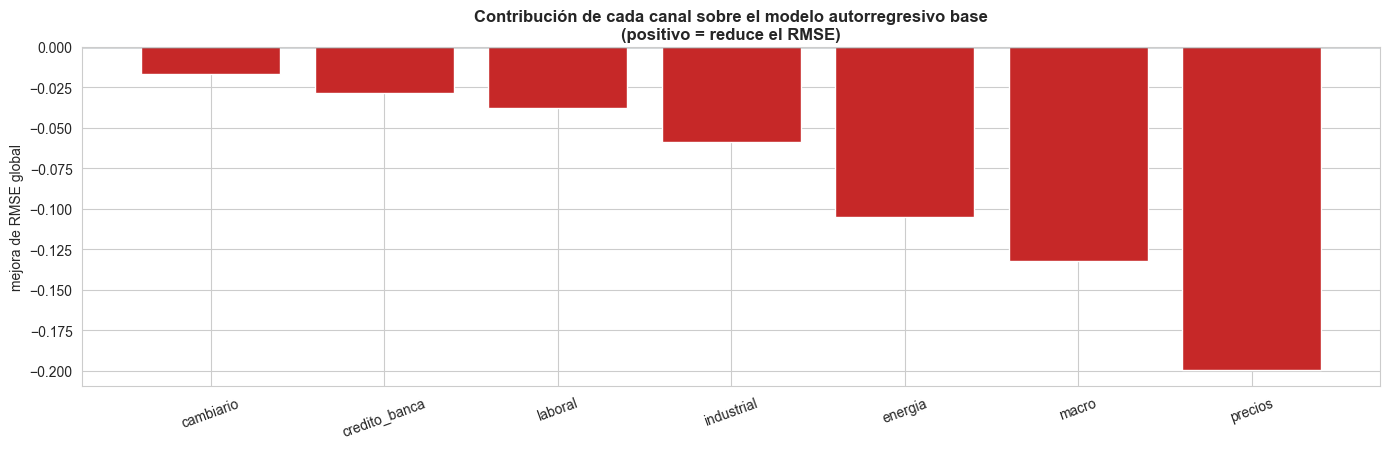

In [4]:
fig, ax = plt.subplots(figsize=(14, 4.6))
canales_solo = tabla.drop(["AR base", "todos"], errors="ignore")
colores = ["#2e7d32" if v > 0 else "#c62828" for v in canales_solo["contribucion"]]
ax.bar(canales_solo.index, canales_solo["contribucion"], color=colores)
ax.axhline(0, color="#37474f", lw=1)
ax.set_title("Contribución de cada canal sobre el modelo autorregresivo base\n(positivo = reduce el RMSE)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("mejora de RMSE global"); plt.xticks(rotation=20); plt.tight_layout(); plt.show()

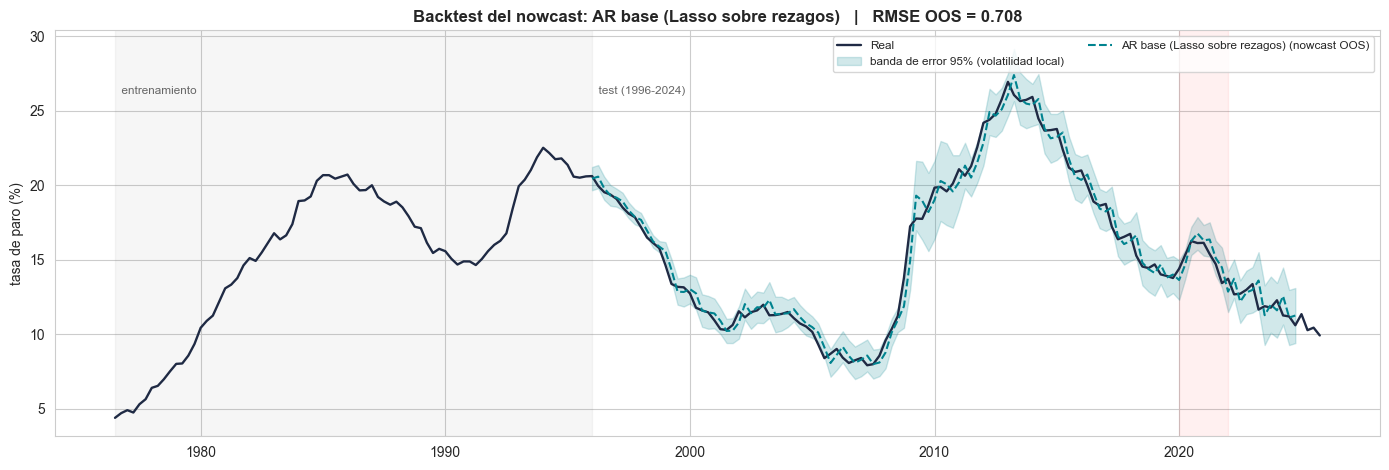

In [5]:
# Backtest del modelo AR base: la referencia contra la que se mide cada canal (la inercia pura del paro)
ar_preds = backtest_preds(CONJUNTOS["AR base"], float(resultados["AR base"]["alpha"]))
plot_backtest(ar_preds, "AR base (Lasso sobre rezagos)", "#00838f")

**Lectura de las contribuciones.** El resultado es inequívoco: **ningún canal económico mejora al modelo autorregresivo base**. La regresión Lasso sobre los rezagos de la propia tasa de paro alcanza un RMSE global de 1.523, que iguala al benchmark ARIMA (1.531), y la incorporación de cualquier canal lo empeora. Las degradaciones van desde -0.017 del canal cambiario, el menos dañino, hasta -0.200 del de precios, el más perjudicial; el canal macro, que contiene el PIB y la brecha de producción de la ley de Okun, resta -0.132, y el conjunto de los siete canales juntos resta -0.146. Solo en el nowcast los regresores contemporáneos aportan algo, pues el conjunto completo baja a 0.556 frente a 0.708 del modelo base, pero esa mejora puntual no se sostiene a horizontes mayores, donde el ruido de las decenas de regresores domina y el error global sube. La conclusión cierra la cuestión que ya señalaban el SARIMAX, Prophet y los modelos de aprendizaje automático: la información económica del panel no añade capacidad predictiva sobre la inercia de la serie.

## 4. Qué variables retiene el modelo

Lasso pone a cero los regresores que no aportan. Ajustando el modelo con todos los canales sobre la
muestra completa, los coeficientes no nulos muestran qué variables sobreviven a la regularización, es
decir, las que el modelo considera útiles más allá de la inercia.

In [6]:
feats_todos = CONJUNTOS["todos"]
a_todos = resultados["todos"]["alpha"]
tr = pd.concat([df[feats_todos], y.rename("y")], axis=1).dropna()
Xs = (tr[feats_todos] - tr[feats_todos].mean()) / tr[feats_todos].std().replace(0, 1)
modelo = Lasso(alpha=a_todos, max_iter=5000).fit(Xs, tr["y"])
coef = pd.DataFrame({"variable": feats_todos, "coef": modelo.coef_})
coef["abs"] = coef["coef"].abs()
no_nulos = coef[coef["abs"] > 1e-8].sort_values("abs", ascending=False).reset_index(drop=True)
print(f"variables retenidas (coeficiente no nulo): {len(no_nulos)} de {len(feats_todos)}")
no_nulos[["variable", "coef"]].head(15)

variables retenidas (coeficiente no nulo): 31 de 60


,variable,coef
0,tasa_paro_total_lag1,4.737100
1,brecha_genero_empleo,-0.213283
2,peso_servicios_pib,0.202776
3,crecimiento_pib_yoy,-0.146646
4,share_empleo_publico,0.143557
5,brecha_output_hp,0.115246
6,apertura_comercial,-0.098795
7,ratio_asalariados,-0.093060
8,saldo_comercial_pct_pib,-0.083382
9,spread_gbp_usd,0.069312


**Lectura de las variables retenidas.** El coeficiente del primer rezago del paro, 4.74, domina por completo, frente a unos regresores cuyos coeficientes no superan en valor absoluto 0.21. Entre los que la regularización no anula aparecen, de forma coherente con la teoría, variables del mercado laboral (`brecha_genero_empleo`, `share_empleo_publico`, `ratio_asalariados`) y de la ley de Okun (`crecimiento_pib_yoy`, `brecha_output_hp`, `okun_residuo`), pero su peso es marginal: Lasso los retiene con un coeficiente pequeño y, como muestra el análisis de contribución, su presencia no reduce el error fuera de muestra. Es la confirmación, desde los coeficientes, de que el panel rodea una señal, la persistencia del paro, que ya está contenida en la propia serie.

---
## 5. Causalidad de Granger

El análisis de contribución mide si un canal mejora el pronóstico. El contraste de causalidad de Granger responde a una pregunta complementaria y **direccional**: ¿los valores pasados de un regresor ayudan a predecir la tasa de paro más allá de lo que ya predice su propio pasado? Si la respuesta es sí, se dice que el regresor **causa en sentido de Granger** a la tasa de paro. Es la forma de ver hacia dónde se mueve la relación, del regresor al paro, frente a la mera correlación. Se contrasta cada variable con un rezago de hasta cuatro trimestres y se reporta el p-valor más significativo.

In [7]:
import contextlib, io as _io
from statsmodels.tsa.stattools import grangercausalitytests

# para cada variable de canal: ¿sus rezagos ayudan a predecir el paro? (direccion regresor -> paro)
candidatas = sorted({v for c in CANALES for v in VARS_CANAL[c]})
filas = []
for v in candidatas:
    sub = df[[TARGET, v]].dropna()
    if len(sub) < 30 or sub[v].std() == 0:
        continue
    try:
        with contextlib.redirect_stdout(_io.StringIO()):
            res = grangercausalitytests(sub[[TARGET, v]], maxlag=4)
        pvals = {lag: res[lag][0]["ssr_ftest"][1] for lag in res}   # p-valor del test F por rezago
        best = min(pvals, key=pvals.get)
        filas.append({"variable": v, "p_min": round(pvals[best], 4), "rezago": best})
    except Exception:
        pass
granger = pd.DataFrame(filas).sort_values("p_min").reset_index(drop=True)
granger["causa_paro_5pct"] = granger["p_min"] < 0.05
print(f"variables que causan en sentido de Granger a la tasa de paro (p<0.05): {int(granger['causa_paro_5pct'].sum())} de {len(granger)}")
granger

variables que causan en sentido de Granger a la tasa de paro (p<0.05): 42 de 55


,variable,p_min,rezago,causa_paro_5pct
0,IPC_2025,0.0000,4,True
1,IPRI_energia_2025,0.0000,4,True
2,IPRI_bienes_intermedios_2025,0.0000,4,True
3,IPRI_bienes_consumo_2025,0.0000,2,True
4,IPRI_total_industria_2025,0.0000,4,True
5,brecha_output_hp,0.0000,4,True
6,brecha_genero_empleo,0.0000,1,True
7,apertura_comercial,0.0000,3,True
8,consumo_publico_pct_pib,0.0000,4,True
9,consumo_publico,0.0000,4,True


**Lectura de la causalidad de Granger.** El contraste detecta que 42 de las 55 variables causan en sentido de Granger a la tasa de paro (p<0.05): los índices de precios (IPC, IPRI), la brecha de producción de la ley de Okun, la brecha de género en el empleo o la apertura comercial encabezan la lista con p-valores prácticamente nulos. El resultado, en apariencia, contradice el análisis de contribución, donde ningún canal mejoraba el pronóstico. La conciliación es la clave metodológica del cuaderno: la causalidad de Granger es un contraste **en muestra**, que detecta que los rezagos de un regresor están asociados con el paro y tienen estructura de adelanto-retardo, pero **no implica que mejoren el pronóstico fuera de muestra**. Que muchas variables causen al paro en sentido de Granger y, a la vez, ninguna reduzca el error de test confirma que esa información ya está contenida en la propia inercia de la serie: el regresor adelanta al paro, pero el paro del trimestre anterior lo adelanta igual o mejor. Es la diferencia entre significancia estadística en muestra y valor predictivo añadido fuera de muestra.

## 6. Cierre

Este cuaderno no añade modelos al ranking ni al ensamblaje: es un análisis de contribución que cierra, canal por canal, la cuestión del valor predictivo de la información económica sobre la tasa de paro.

**Checkpoint de honestidad.**

- **Hecho.** Contribución de los siete canales económicos sobre un modelo autorregresivo base, en el mismo expanding window y con la misma selección de `alpha` por camino data-driven.
- **Hallazgo.** Ningún canal mejora al modelo base, una regresión Lasso sobre los rezagos del paro con un RMSE global de 1.523 que iguala al ARIMA. Todos restan, de -0.017 del cambiario a -0.200 de precios; el conjunto de los siete resta -0.146.
- **Variables.** El primer rezago del paro domina con un coeficiente de 4.74; los regresores que sobreviven a la regularización, del mercado laboral y de la ley de Okun, tienen pesos diminutos.
- **Conclusión.** La información económica del panel no añade sobre la inercia de la serie. Cierra de forma ordenada lo que el SARIMAX, Prophet y los modelos de aprendizaje automático ya apuntaban.